# **AirQuality Index PredictionModel**



In [ ]:
# Import Data Manipulation Libraries
import numpy as np
import pandas as pd

# Import Data Visualization Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Import Filter Warnings Libraries
import warnings
warnings.filterwarnings(action = 'ignore')

# Import Logging
import logging
logging.basicConfig(filename = 'model.log',
                    format = '%(asctime)s - %(message)s - %(levelname)s',
                    filemode = 'w',
                    level = logging.INFO)

# Import Machine Learning Libraries
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split

# Import Machine Learning Model Building Libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor


In [ ]:
# Step1: Data Ingestion

df = pd.read_excel(r'/content/AirQualityUCI.xlsx')
df.head()


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [ ]:
# Checking Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes: datetime64[ns](1),

In [ ]:
# Dropping Unwanted Columns

df.drop(columns = ['Date', 'Time'],inplace = True)


In [32]:
# Segregate Numerical data and Categorical Data

numerical_data = df.select_dtypes(exclude = 'object')
categorical_data = df.select_dtypes(include = 'object')

# Calculate Q1,Q3 and IQR

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
Outliers = df[((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis = 1)]
print('Number of Outliers :', len(Outliers))

# Calculate outlier statistics

outlier_count = Outliers.count()
outlier_percentage = (outlier_count / df[i].count()) * 100



# Calculate Descriptive stats for Numerical Columns


from collections import OrderedDict

stats = []

for i in numerical_data.columns:

    # Q1, Q3 and IQR
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    # Lower and Upper limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Outlier condition
    outlier_condition = (df[i] < lower_limit) | (df[i] > upper_limit)

    # Number of outliers
    outlier_count = int(outlier_condition.sum())

    # Outlier percentage
    valid_count = df[i].notna().sum()

    if valid_count > 0:
        outlier_percentage = (outlier_count / valid_count) * 100
    else:
        outlier_percentage = 0

    # Statistics

    numerical_stats = OrderedDict({
        'Feature': i,
        'Count': df[i].count(),
        'Missing Values %': (df[i].isnull().sum() / len(df[i])) * 100,
        'Maximum': df[i].max(),
        'Minimum': df[i].min(),
        'Mean': df[i].mean(),
        'Median': df[i].median(),
        'Q1': Q1,
        'Q3': Q3,
        'Var': df[i].var(),
        'IQR': IQR,
        'Outlier Count': outlier_count,
        'Outlier %': outlier_percentage,
        'Outliers Present': 'Yes' if outlier_count > 0 else 'No',
        'Kurtosis': df[i].kurtosis(),
        'Standard Deviation': df[i].std(),
        'Variance': df[i].var()
    })

    stats.append(numerical_stats)

report = pd.DataFrame(stats)

report

Number of Outliers : 3459


,Feature,Count,Missing Values %,Maximum,Minimum,Mean,Median,Q1,Q3,Var,IQR,Outlier Count,Outlier %,Outliers Present,Kurtosis,Standard Deviation,Variance
0,CO(GT),9357,0.0,4.700000,-200.000000,-34.267960,1.500000,0.600000,2.600000,6025.788747,2.000000,1683,17.986534,Yes,0.778763,77.625954,6025.788747
1,PT08.S1(CO),9357,0.0,1501.750000,745.500000,1080.352864,1052.500000,921.000000,1221.250000,43603.400154,300.250000,0,0.000000,No,-0.691228,208.814272,43603.400154
2,NMHC(GT),9357,0.0,145.000000,-200.000000,-169.805066,-200.000000,-200.000000,-200.000000,8613.585126,0.000000,914,9.768088,Yes,6.100387,92.809402,8613.585126
3,C6H6(GT),9357,0.0,24.455875,0.734469,9.431888,7.886653,4.004958,13.636091,44.696682,9.631133,0,0.000000,No,-0.392317,6.685558,44.696682
4,PT08.S2(NMHC),9357,0.0,1415.250000,470.750000,914.245912,894.500000,711.000000,1104.750000,67860.967867,393.750000,0,0.000000,No,-0.813951,260.501378,67860.967867
5,NOx(GT),9357,0.0,654.000000,-200.000000,159.277984,141.000000,50.000000,284.200000,54035.169661,234.200000,509,5.439778,Yes,-0.283511,232.454662,54035.169661
6,PT08.S3(NOx),9357,0.0,1281.500000,409.750000,807.971403,794.250000,637.000000,960.250000,54601.257791,323.250000,0,0.000000,No,-0.623171,233.669120,54601.257791
7,NO2(GT),9357,0.0,194.000000,-200.000000,56.658331,96.000000,53.000000,133.000000,15629.752012,80.000000,1642,17.548360,Yes,0.307251,125.019007,15629.752012
8,PT08.S4(NO2),9357,0.0,2020.500000,756.500000,1419.758657,1445.500000,1184.750000,1662.000000,118084.336754,477.250000,0,0.000000,No,-0.709050,343.634016,118084.336754
9,PT08.S5(O3),9357,0.0,1750.250000,347.750000,986.543639,942.000000,699.750000,1255.250000,149996.361760,555.500000,0,0.000000,No,-0.740690,387.293638,149996.361760


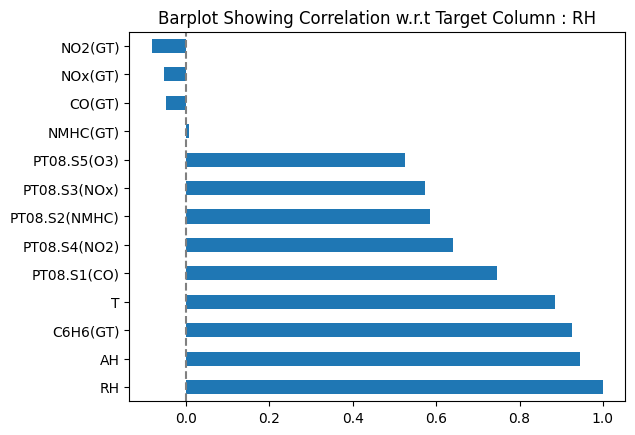

In [25]:
df.corr()['RH'].sort_values(ascending= False).plot(kind = 'barh')
plt.title('Barplot Showing Correlation w.r.t Target Column : RH')
plt.axvline(0,color = 'gray',linestyle = '--')
plt.show()


In [26]:
# Using Winsorization Technique to Capp the Outliers with LowerBound and UpperBound

'''

Obervation:
- Data contains outliers in maximum columns
- Data is Skewed and contains outliers which makes machine model overfit.
- So Hence, We use Winsorization Technique to Capp the Outliers with LowerBound and UpperBound.

'''
from scipy.stats.mstats import winsorize

for i in df.select_dtypes(exclude = 'object').columns:
  df[i] = winsorize(df[i],limits = [0.05,0.05])  #(lower_limit,upper_limit)


df['RH'].max(),df['RH'].median(),df['RH'].min()

(77.625001907349, 48.550000190735, 15.025000095367)

In [27]:
# Model Building

'''

Step1: Split the Data into X and y
Step2: Use Train and Test Split
Step3: Use Scaling Technique
Step4: Model Building

'''

# Step1: Split the Dataset into X and y
X = df.drop(columns = ['RH'],axis = 1)
y = df['RH']

# Step2: Use Train and Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size = 0.3,
                                                 random_state =1)
# Step3: Use Scale Technique
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Model Building

from sklearn.metrics import r2_score

models = {
    'DecisionTreeRegressor':DecisionTreeRegressor(),
    'RandomForestRegressor':RandomForestRegressor(),
    'ExtraTreesRegressor':ExtraTreesRegressor(),
    'KNeighborsRegressor':KNeighborsRegressor()

}

for model_name,model in models.items():
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  print(r2_score(y_test,y_pred))

0.9906966257879212
0.9964838443957682
0.9964221906756108
0.93355722538925


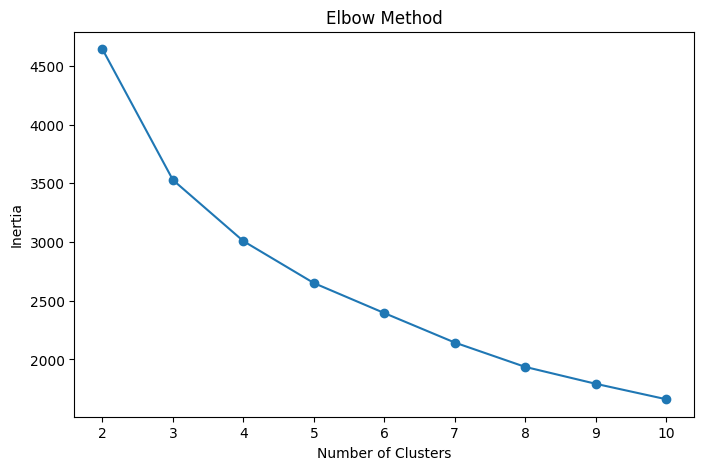

In [28]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_train)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


In [29]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(r2_score(y_test,y_pred))

0.93355722538925


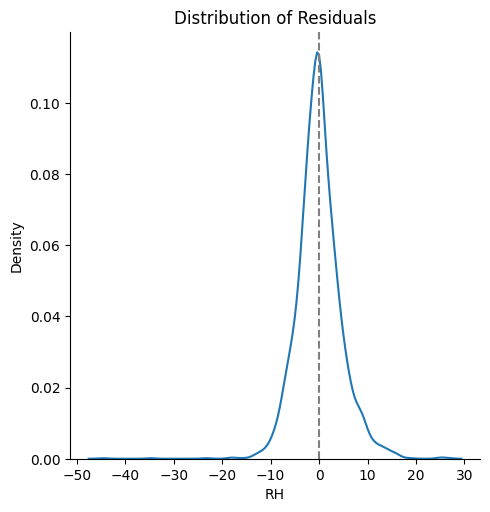

In [30]:
sns.displot(y_test-y_pred,kind = 'kde')
plt.axvline(0,color = 'gray',linestyle = '--')
plt.title('Distribution of Residuals')
plt.show()

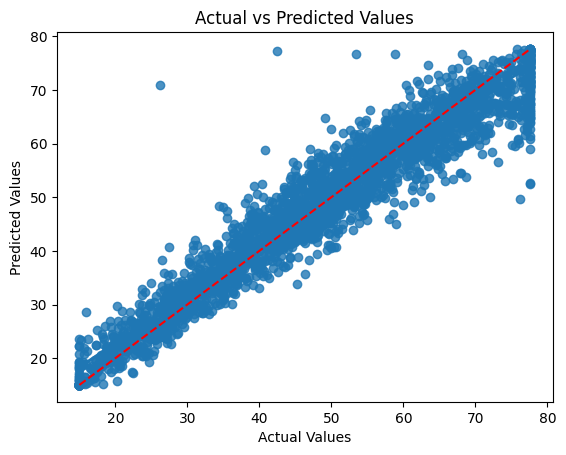

In [31]:
sns.regplot(x = y_test,y = y_pred)
sns.lineplot(x = y_test,y = y_test,color = 'red',linestyle = '--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()